# Task 4: Variational Auto-Encoders

## Importing Libraries

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import os, pickle
import numpy as np
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


## 1. Building Basic VAE

### Loading and Initializing Dataset MNIST

In [2]:
transform = transforms.Compose([transforms.ToTensor()])

MNIST_trainset = datasets.MNIST('./data', train=True, transform=transform, download=True)
MNIST_testset = datasets.MNIST('./data', train=False, transform=transform, download=True)


MNIST_trainloader = DataLoader(MNIST_trainset, batch_size=256, shuffle=True)
MNIST_testloader = DataLoader(MNIST_testset, batch_size=256, shuffle=False)

### VAE Implementation

In [3]:
class VAE(nn.Module):
    def __init__(self, latent_dim=10):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        self.mu = nn.Linear(128*7*7, latent_dim)
        self.logvar = nn.Linear(128*7*7, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, 128 * 7 * 7)

        self.decoder = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 1, kernel_size=2, stride=2), 
            nn.Sigmoid()
        )

    def encode(self, x):
        return self.encoder(x)

    def reparametrize(self, enc):
        batch_size = enc.size(0)
        enc = enc.reshape(batch_size, -1)
        mu = self.mu(enc)
        logvar = self.logvar(enc)
        eps = torch.randn(batch_size, self.latent_dim).to(mu.device)

        z = mu + torch.exp(0.5 * logvar) * eps

        return z, mu, logvar

    def decode(self, z):
        dec = self.fc_decode(z)
        B = dec.size(0)
        dec = dec.reshape(B, 128, 7, 7)
        out = self.decoder(dec)

        return out

    def forward(self, x):
        enc = self.encode(x)
        z, mu, logvar = self.reparametrize(enc)
        out = self.decode(z)

        return out, mu, logvar

In [4]:
def vae_loss(recon_x, x, mu, logvar, lambda_k=1):
    recon_loss = torch.mean(torch.sum((x - recon_x)**2, dim=(1,2,3)))
    kld_loss = torch.mean(torch.sum(-0.5 * (1 + logvar - mu**2 - torch.exp(logvar)), dim=1))
    total_loss = recon_loss + lambda_k * kld_loss
    return total_loss, recon_loss, kld_loss

### Training Loop

In [5]:
def train_epoch(dataloader, model, criterion, optimizer):
    model.train(True)
    running_loss = 0
    running_kld_loss = 0
    running_recon_loss = 0
    total = 0

    for samples, _ in tqdm(dataloader):
        samples = samples.to(device)
        batch_size = samples.size(0)

        recon, mu, logvar = model(samples)
        optimizer.zero_grad()
        loss, recon_loss, kld_loss = criterion(recon, samples, mu, logvar)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_size
        running_kld_loss += kld_loss.item() * batch_size
        running_recon_loss += recon_loss.item() * batch_size
        total += batch_size

    avg_loss = running_loss / total
    avg_kld_loss = running_kld_loss / total
    avg_recon_loss = running_recon_loss / total

    return avg_loss, avg_kld_loss, avg_recon_loss

In [6]:
def evaluate_epoch(dataloader, model, criterion):
    model.eval()
    running_loss = 0
    running_kld_loss = 0
    running_recon_loss = 0
    total = 0

    with torch.no_grad():
        for samples, _ in tqdm(dataloader):
            samples = samples.to(device)
            batch_size = samples.size(0)

            recon, mu, logvar = model(samples)
            loss, recon_loss, kld_loss = criterion(recon, samples, mu, logvar, 1)

            running_loss += loss.item() * batch_size
            running_kld_loss += kld_loss.item() * batch_size
            running_recon_loss += recon_loss.item() * batch_size
            total += batch_size

    avg_loss = running_loss / total
    avg_kld_loss = running_kld_loss / total
    avg_recon_loss = running_recon_loss / total

    return avg_loss, avg_kld_loss, avg_recon_loss

In [7]:
EPOCHS = 20
LR = 1e-4
vae_model = VAE().to(device)
optimizer = torch.optim.Adam(vae_model.parameters(), lr=LR)
criterion = vae_loss

TRAIN_LOSS = []
TRAIN_KLD_LOSS = []
TRAIN_RECON_LOSS = []

TEST_LOSS = []
TEST_KLD_LOSS = []
TEST_RECON_LOSS = []


for i in range(EPOCHS):
    train_loss, train_kld_loss, train_recon_loss = train_epoch(MNIST_trainloader, vae_model, vae_loss, optimizer)
    test_loss, test_kld_loss, test_recon_loss = evaluate_epoch(MNIST_testloader, vae_model, vae_loss)

    TRAIN_LOSS.append(train_loss)
    TRAIN_KLD_LOSS.append(train_kld_loss)
    TRAIN_RECON_LOSS.append(train_recon_loss)

    TEST_LOSS.append(test_loss)
    TEST_KLD_LOSS.append(test_kld_loss)
    TEST_RECON_LOSS.append(test_recon_loss)

    print(f"Epoch {i+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | KLD: {train_kld_loss:.4f} | Recon: {train_recon_loss:.4f}")
    print(f"Epoch {i+1}/{EPOCHS} | Test  Loss: {test_loss:.4f} | KLD: {test_kld_loss:.4f} | Recon: {test_recon_loss:.4f}")

os.makedirs('./models', exist_ok=True)
torch.save(vae_model.state_dict(), './models/vae_mnist.pth')

with open('./models/vae_mnist_hist.pkl', 'wb') as file:
    pickle.dump({
        'train_loss': TRAIN_LOSS,
        'train_kld_loss': TRAIN_KLD_LOSS,
        'train_recon_loss': TRAIN_RECON_LOSS,
        'test_loss': TEST_LOSS,
        'test_kld_loss': TEST_KLD_LOSS,
        'test_recon_loss': TEST_RECON_LOSS,
    }, file)

100%|██████████| 40/40 [00:01<00:00, 33.61it/s]


Epoch 1/20 | Train Loss: 161.9047 | KLD: 7.9182 | Recon: 153.9865
Epoch 1/20 | Test  Loss: 120.5048 | KLD: 6.4192 | Recon: 114.0856


100%|██████████| 40/40 [00:00<00:00, 54.01it/s]


Epoch 2/20 | Train Loss: 104.3976 | KLD: 5.1962 | Recon: 99.2013
Epoch 2/20 | Test  Loss: 90.9081 | KLD: 5.2644 | Recon: 85.6437


100%|██████████| 40/40 [00:00<00:00, 52.70it/s]


...

Epoch 18/20 | Train Loss: 31.1659 | KLD: 11.0372 | Recon: 20.1287
Epoch 18/20 | Test  Loss: 30.6591 | KLD: 11.0062 | Recon: 19.6529


100%|██████████| 40/40 [00:01<00:00, 33.22it/s]


Epoch 19/20 | Train Loss: 30.9092 | KLD: 11.1093 | Recon: 19.7999
Epoch 19/20 | Test  Loss: 30.4695 | KLD: 11.2935 | Recon: 19.1760


100%|██████████| 40/40 [00:01<00:00, 33.99it/s]

Epoch 20/20 | Train Loss: 30.7172 | KLD: 11.1773 | Recon: 19.5399
Epoch 20/20 | Test  Loss: 30.3114 | KLD: 11.4521 | Recon: 18.8593


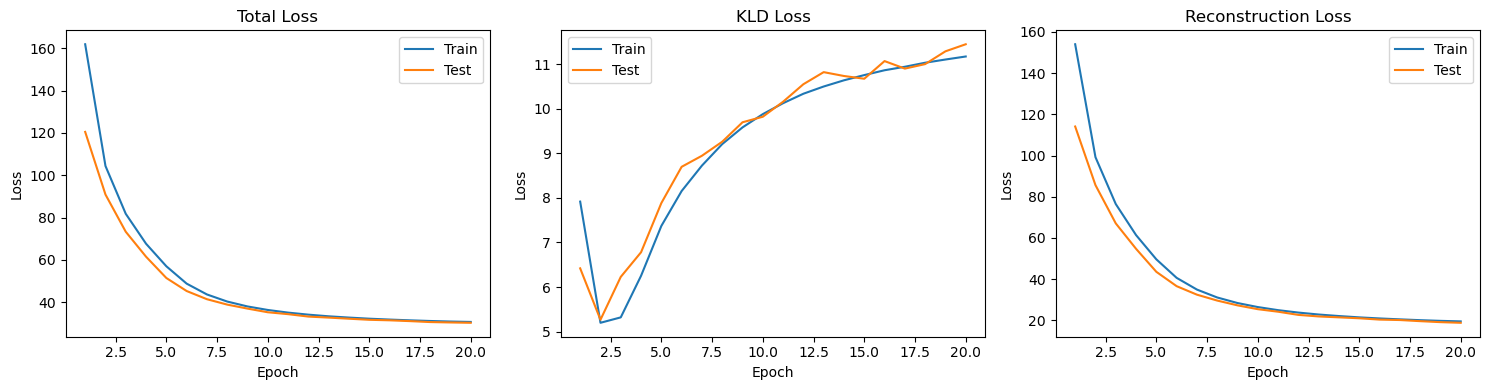

In [8]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_range, TRAIN_LOSS, label='Train')
axes[0].plot(epochs_range, TEST_LOSS, label='Test')
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs_range, TRAIN_KLD_LOSS, label='Train')
axes[1].plot(epochs_range, TEST_KLD_LOSS, label='Test')
axes[1].set_title('KLD Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

axes[2].plot(epochs_range, TRAIN_RECON_LOSS, label='Train')
axes[2].plot(epochs_range, TEST_RECON_LOSS, label='Test')
axes[2].set_title('Reconstruction Loss')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].legend()

plt.tight_layout()
plt.show()

## 2. Analyzing VAE Performance

### a) Latent Space Visualization

Extracting latent:: 100%|██████████| 40/40 [00:02<00:00, 13.93it/s]
c:\Users\Syed Daniyal\.conda\envs\torch_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


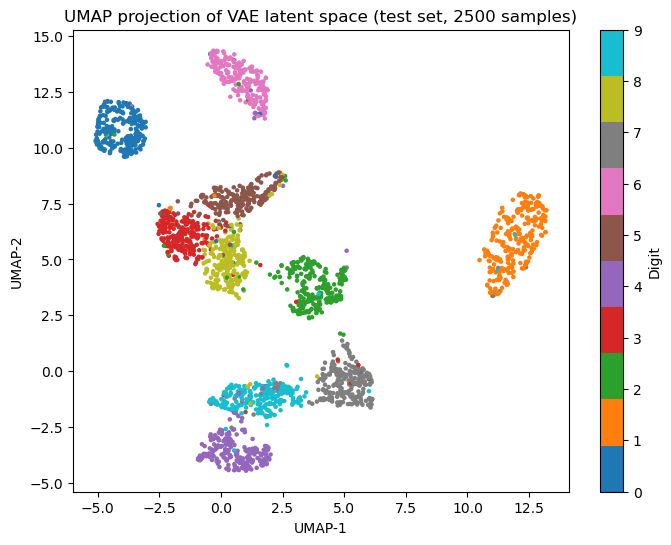

In [11]:
import umap.umap_

vae_model.eval()
Z, LABELS = [], []

with torch.no_grad():
    for samples, labels in tqdm(MNIST_testloader, desc='Extracting latent:'):
        samples = samples.to(device)
        enc = vae_model.encode(samples)
        mu, logvar = vae_model.mu(enc.reshape(enc.size(0), -1)), vae_model.logvar(enc.reshape(enc.size(0), -1))
        Z.append(mu.cpu().numpy())
        LABELS.append(labels.numpy())

Z = np.concatenate(Z, axis=0)
LABELS = np.concatenate(LABELS, axis=0)

reducer = umap.UMAP(n_components=2, random_state=42)
Z_2d = reducer.fit_transform(Z)

idx = np.random.choice(len(Z_2d), size=2500, replace=False)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(Z_2d[idx, 0], Z_2d[idx, 1], c=LABELS[idx], cmap='tab10', s=5)
plt.colorbar(scatter, ticks=range(10), label='Digit')
plt.title('UMAP projection of VAE latent space (test set, 2500 samples)')
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.show()

### Analysis

It properly shows that the latent space has organized and clustered points of each unique digit class together in a group which is highlighted by colors in the scatter plot above.

### b) Reconstruction: Inference

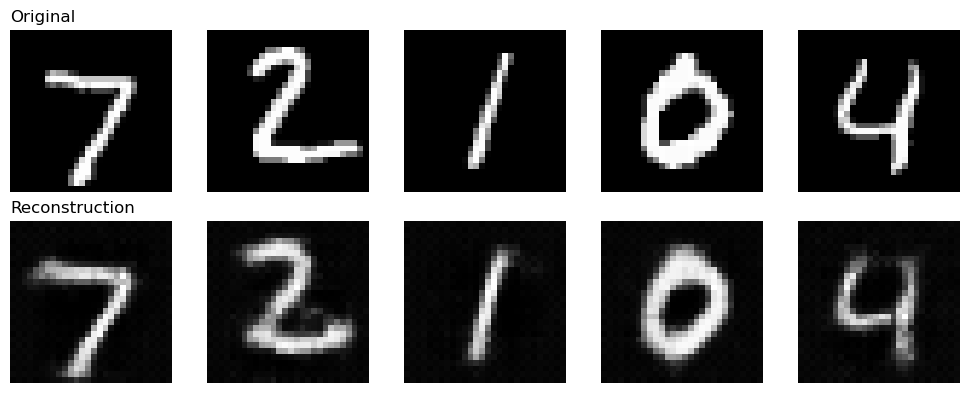

In [12]:
vae_model.eval()
samples, _ = next(iter(MNIST_testloader))
samples = samples[:5].to(device)

with torch.no_grad():
    recon, mu, logvar = vae_model(samples)

samples = samples.cpu().numpy()
recon = recon.cpu().numpy()

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i in range(5):
    axes[0, i].imshow(samples[i, 0], cmap='gray')
    axes[0, i].axis('off')

    axes[1, i].imshow(recon[i, 0], cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_title('Original', loc='left', fontsize=12)
axes[1, 0].set_title('Reconstruction', loc='left', fontsize=12)

plt.tight_layout()
plt.show()

### c) Generation From Random Z

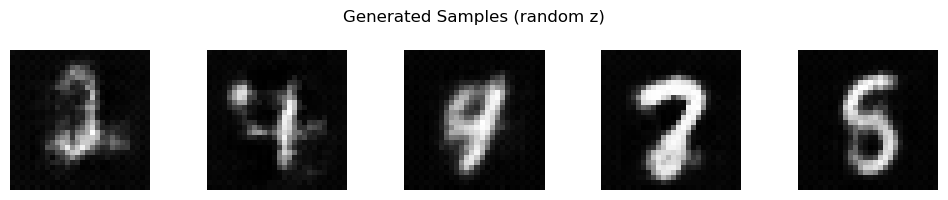

In [14]:
vae_model.eval()

with torch.no_grad():
    z = torch.randn(5, vae_model.latent_dim).to(device)
    generated = vae_model.decode(z)

generated = generated.cpu().numpy()

fig, axes = plt.subplots(1, 5, figsize=(10, 2))

for i in range(5):
    axes[i].imshow(generated[i, 0], cmap='gray')
    axes[i].axis('off')

plt.suptitle('Generated Samples (random z)')
plt.tight_layout()
plt.show()

## 3. Comparing with Doersch’s VAE Implementation

**Architecture**

Doersch's implementation is a fully connected (MLP) VAE built in Caffe, adapted from Caffe's standard MNIST autoencoder example. It uses ReLU activations and Adam optimizer, but it does not use any convolutional layers.

My model is a convolutional VAE (CNN based), not an MLP. The encoder has 3 conv blocks (32, 64, 128 filters) with batch norm, ReLU, and max pooling. The decoder uses transposed convolutions to upsample back to 28x28. Since Doersch's model is fully connected, my architecture is deeper and spatially aware, which should capture pixel neighborhood structure better than an MLP.

**Output Distribution and Loss**

Doersch treats MNIST pixel intensities as probabilities and uses Sigmoid Cross Entropy loss, which corresponds to modeling each pixel as an independent Bernoulli variable. This is his P(X|z).

My implementation is different. I used a Sigmoid activation on the output (so pixel values are between 0 and 1), but for the reconstruction loss I used Mean Squared Error (sum of squared differences per image, averaged over batch), not Binary Cross Entropy. So my model is implicitly assuming a Gaussian output distribution rather than a Bernoulli one. This does not match Doersch's setup.

**Latent Dimensionality**

I used a latent dimension of 10. I did not experiment with other sizes in this notebook, so I cannot directly comment on training difficulty or reconstruction quality across different latent sizes. Based on the UMAP projection of the latent space, the 10-dim latent space is enough to separate all 10 digit classes into distinct clusters, which agrees with Doersch's observation that the VAE is fairly insensitive to z dimensionality as long as it is not too small or too large.

**Results Comparison**

Doersch reports that his generated digits mostly look realistic and coherent, with only a few ambiguous "in-between" digits.

My results are reasonably similar but a bit weaker. The reconstructions (original vs reconstructed digits) look clean and correctly capture digit identity and stroke shape, though slightly blurred, which is expected from the pixel-wise MSE loss and the KLD regularization. 

For random generation (sampling z from N(0, I) and decoding), most samples are recognizable digits (e.g., 3, 4, 5, 7 in my generated samples), but I also see one clear failure case: one generated sample looks like a blend between a 5 and an 8, similar to the "in-between" ambiguous digit issue Doersch mentions. Overall, my model performs comparably to Doersch's in terms of reconstruction quality, but generation from pure random noise is a bit less sharp, likely because of the MSE loss instead of BCE, and possibly needing more training epochs.